In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder

plt.style.use('ggplot')

%matplotlib inline

# Dataset Analysis

In [2]:
# Import the dataset
dataset = pd.read_csv('Data_Cortex_Nuclear.csv')
dataset.head()

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


In [3]:
dataset.describe()

,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,SHH_N,BAD_N,BCL2_N,pS6_N,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N
count,1077.000000,1077.000000,1077.000000,1077.000000,1077.000000,1077.000000,1077.000000,1077.000000,1077.000000,1077.000000,...,1080.000000,867.000000,795.000000,1080.000000,1005.000000,1080.000000,900.000000,870.000000,810.000000,1080.000000
mean,0.425810,0.617102,0.319088,2.297269,3.843934,0.233168,0.181846,3.537109,0.212574,1.428682,...,0.226676,0.157914,0.134762,0.121521,0.131053,0.446073,0.169609,0.183135,0.205440,1.337784
std,0.249362,0.251640,0.049383,0.347293,0.933100,0.041634,0.027042,1.295169,0.032587,0.466904,...,0.028989,0.029537,0.027417,0.014276,0.023863,0.066432,0.059402,0.040406,0.055514,0.317126
min,0.145327,0.245359,0.115181,1.330831,1.737540,0.063236,0.064043,1.343998,0.112812,0.429032,...,0.155869,0.088305,0.080657,0.067254,0.085419,0.258626,0.079691,0.105537,0.101787,0.586479
25%,0.288121,0.473361,0.287444,2.057411,3.155678,0.205755,0.164595,2.479834,0.190823,1.203665,...,0.206395,0.136424,0.115554,0.110839,0.113506,0.398082,0.125848,0.155121,0.165143,1.081423
50%,0.366378,0.565782,0.316564,2.296546,3.760855,0.231177,0.182302,3.326520,0.210594,1.355846,...,0.224000,0.152313,0.129468,0.121626,0.126523,0.448459,0.158240,0.174935,0.193994,1.317441
75%,0.487711,0.698032,0.348197,2.528481,4.440011,0.257261,0.197418,4.481940,0.234595,1.561316,...,0.241655,0.174017,0.148235,0.131955,0.143652,0.490773,0.197876,0.204542,0.235215,1.585824
max,2.516367,2.602662,0.497160,3.757641,8.482553,0.539050,0.317066,7.464070,0.306247,6.113347,...,0.358289,0.282016,0.261506,0.158748,0.256529,0.759588,0.479763,0.360692,0.413903,2.129791


In [4]:
print ("Rows:", dataset.shape[0])
print ("Columns:", dataset.shape[1])

Rows: 1080
Columns: 82


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MouseID          1080 non-null   object 
 1   DYRK1A_N         1077 non-null   float64
 2   ITSN1_N          1077 non-null   float64
 3   BDNF_N           1077 non-null   float64
 4   NR1_N            1077 non-null   float64
 5   NR2A_N           1077 non-null   float64
 6   pAKT_N           1077 non-null   float64
 7   pBRAF_N          1077 non-null   float64
 8   pCAMKII_N        1077 non-null   float64
 9   pCREB_N          1077 non-null   float64
 10  pELK_N           1077 non-null   float64
 11  pERK_N           1077 non-null   float64
 12  pJNK_N           1077 non-null   float64
 13  PKCA_N           1077 non-null   float64
 14  pMEK_N           1077 non-null   float64
 15  pNR1_N           1077 non-null   float64
 16  pNR2A_N          1077 non-null   float64
 17  pNR2B_N       

In [6]:
# function to separate categorical from numeric features
def feature_types(dataset):
    categ = []
    numer = []
    for c in dataset.columns:
        if dataset[c].dtype == 'object': categ.append(c)
        else: numer.append(c)
    return categ, numer

In [7]:
# display information on categorical features
categorical, numerical = feature_types(dataset)
print('categorical features:', categorical)
print('')

for f in categorical[1:-1]:
    print('value counts of feature: {}'.format(f))
    print(dataset[f].value_counts())
    print('    -------------------------')
    print('')

categorical features: ['MouseID', 'Genotype', 'Treatment', 'Behavior', 'class']

value counts of feature: Genotype
Control    570
Ts65Dn     510
Name: Genotype, dtype: int64
    -------------------------

value counts of feature: Treatment
Memantine    570
Saline       510
Name: Treatment, dtype: int64
    -------------------------

value counts of feature: Behavior
S/C    555
C/S    525
Name: Behavior, dtype: int64
    -------------------------



number of classes:  8
class names:  ['c-CS-m' 'c-SC-m' 'c-CS-s' 'c-SC-s' 't-CS-m' 't-SC-m' 't-CS-s' 't-SC-s']


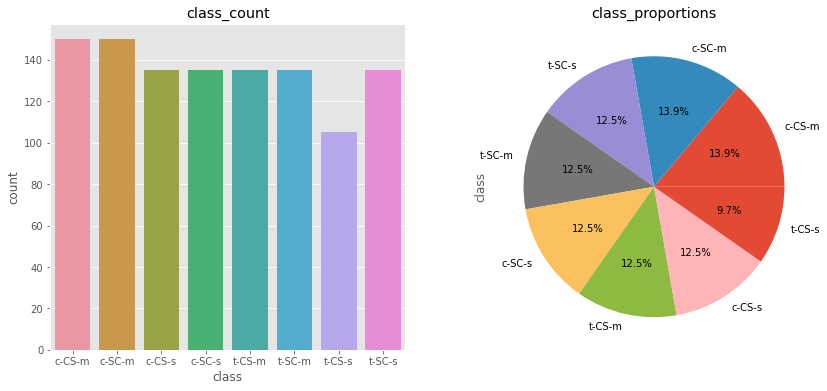

In [8]:
# information on classes
print('number of classes: ',dataset['class'].nunique())
print('class names: ', dataset['class'].unique())

plt.figure(figsize = (14, 6));
plt.subplot(1, 2, 1);
plt.title('class_count');
sns.countplot(x = 'class', data = dataset);
plt.subplot(1, 2, 2);
plt.title('class_proportions');
dataset['class'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%');

total number of missing values: 1396


<AxesSubplot:>

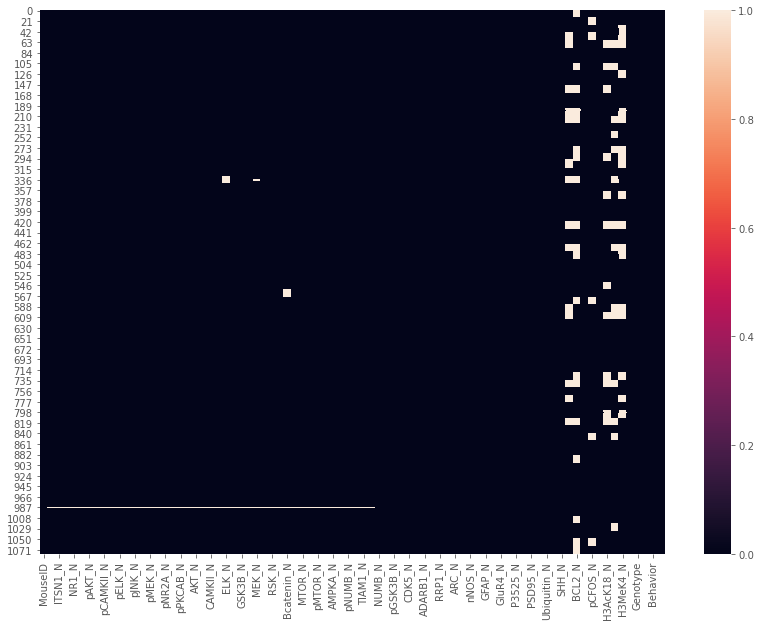

In [9]:
# count and visualize missing values
print('total number of missing values:', dataset.isnull().sum().sum())
plt.figure(figsize = (14, 10))
sns.heatmap(dataset.isnull())

In [10]:
# 5 columns have more than 100 missing values
dataset.isna().sum()[65:]

SNCA_N               0
Ubiquitin_N          0
pGSK3B_Tyr216_N      0
SHH_N                0
BAD_N              213
BCL2_N             285
pS6_N                0
pCFOS_N             75
SYP_N                0
H3AcK18_N          180
EGR1_N             210
H3MeK4_N           270
CaNA_N               0
Genotype             0
Treatment            0
Behavior             0
class                0
dtype: int64

<AxesSubplot:>

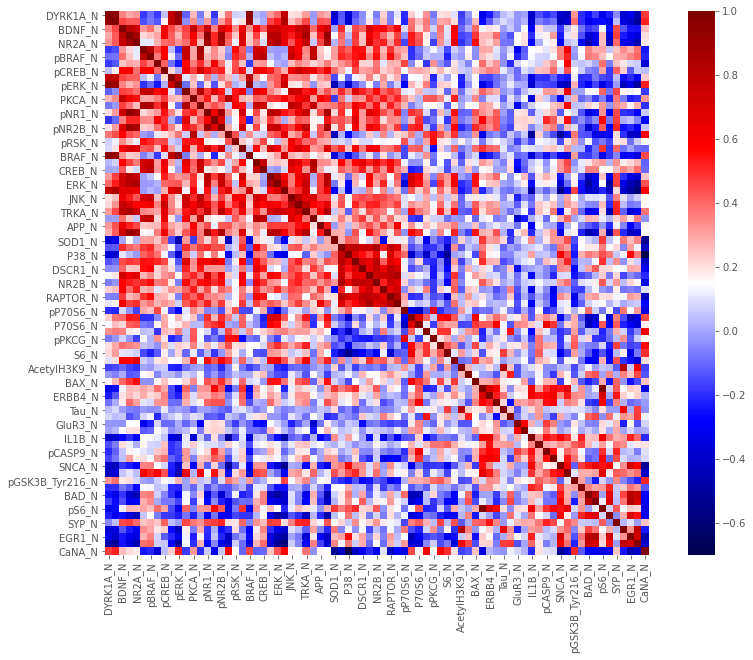

In [11]:
# correlation heatmap
plt.figure(figsize = (14, 10))
sns.heatmap(dataset.corr(), cmap = 'seismic', square = True)

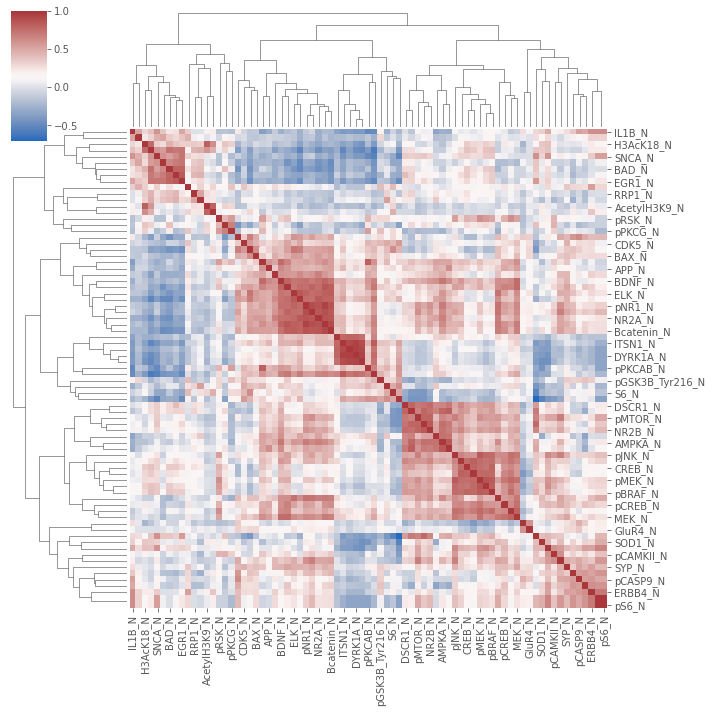

In [12]:
# clustermap
sns.clustermap(dataset.corr(), cmap = 'vlag')

# Drop Null Values

In [13]:
dataset.drop(['MouseID', 'Genotype', 'Treatment', 'Behavior'], axis = 1, inplace = True)

In [14]:
dataset.isnull().sum()[30:]

APP_N                3
Bcatenin_N          18
SOD1_N               3
MTOR_N               3
P38_N                3
pMTOR_N              3
DSCR1_N              3
AMPKA_N              3
NR2B_N               3
pNUMB_N              3
RAPTOR_N             3
TIAM1_N              3
pP70S6_N             3
NUMB_N               0
P70S6_N              0
pGSK3B_N             0
pPKCG_N              0
CDK5_N               0
S6_N                 0
ADARB1_N             0
AcetylH3K9_N         0
RRP1_N               0
BAX_N                0
ARC_N                0
ERBB4_N              0
nNOS_N               0
Tau_N                0
GFAP_N               0
GluR3_N              0
GluR4_N              0
IL1B_N               0
P3525_N              0
pCASP9_N             0
PSD95_N              0
SNCA_N               0
Ubiquitin_N          0
pGSK3B_Tyr216_N      0
SHH_N                0
BAD_N              213
BCL2_N             285
pS6_N                0
pCFOS_N             75
SYP_N                0
H3AcK18_N  

In [15]:
# Drop the five columns with more than 100 null values
dataset.drop(['BAD_N', 'BCL2_N', 'H3AcK18_N', 'EGR1_N', 'H3MeK4_N'], axis = 1, inplace = True)

In [16]:
# Fill in the rest of the null values with the mean
dataset.fillna(dataset.mean(), inplace = True)

In [17]:
dataset.isnull().sum()[30:]

APP_N              0
Bcatenin_N         0
SOD1_N             0
MTOR_N             0
P38_N              0
pMTOR_N            0
DSCR1_N            0
AMPKA_N            0
NR2B_N             0
pNUMB_N            0
RAPTOR_N           0
TIAM1_N            0
pP70S6_N           0
NUMB_N             0
P70S6_N            0
pGSK3B_N           0
pPKCG_N            0
CDK5_N             0
S6_N               0
ADARB1_N           0
AcetylH3K9_N       0
RRP1_N             0
BAX_N              0
ARC_N              0
ERBB4_N            0
nNOS_N             0
Tau_N              0
GFAP_N             0
GluR3_N            0
GluR4_N            0
IL1B_N             0
P3525_N            0
pCASP9_N           0
PSD95_N            0
SNCA_N             0
Ubiquitin_N        0
pGSK3B_Tyr216_N    0
SHH_N              0
pS6_N              0
pCFOS_N            0
SYP_N              0
CaNA_N             0
class              0
dtype: int64

In [18]:
category, numerical = feature_types(dataset)

In [19]:
# Build a PCA model for t-CS-m vs. c-CS-s
PCA_dataset = dataset[(dataset['class'] == 't-CS-m') | (dataset['class'] == 'c-CS-s')]

In [20]:
# Build a classification model for t-CS-m vs. c-CS-s using support vector machine
SVC_dataset = dataset[(dataset['class'] == 't-CS-m') | (dataset['class'] == 'c-CS-s')].copy()
SVC_dataset.loc[:, 'class'].replace({'t-CS-m': 1, 'c-CS-s': 0}, inplace = True)

# PCA Evaluation

number of classes:  2
class names:  ['c-CS-s' 't-CS-m']


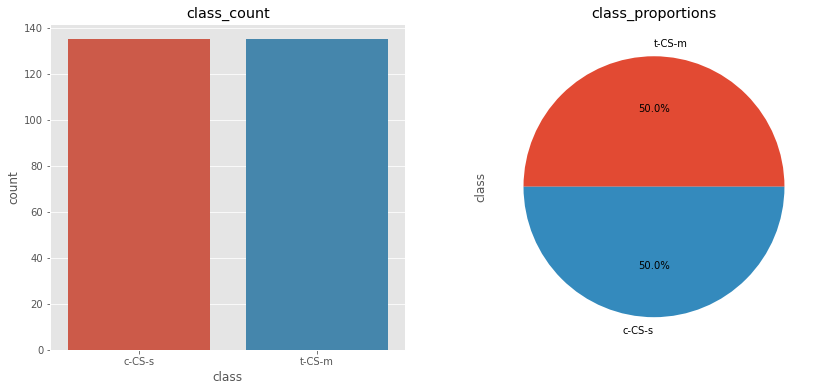

In [21]:
# information on classes
print('number of classes: ',PCA_dataset['class'].nunique())
print('class names: ', PCA_dataset['class'].unique())

plt.figure(figsize = (14, 6));
plt.subplot(1, 2, 1);
plt.title('class_count');
sns.countplot(x = 'class', data = PCA_dataset);
plt.subplot(1, 2, 2);
plt.title('class_proportions');
PCA_dataset['class'].value_counts().plot(kind = 'pie', autopct = '%1.1f%%');

<AxesSubplot:>

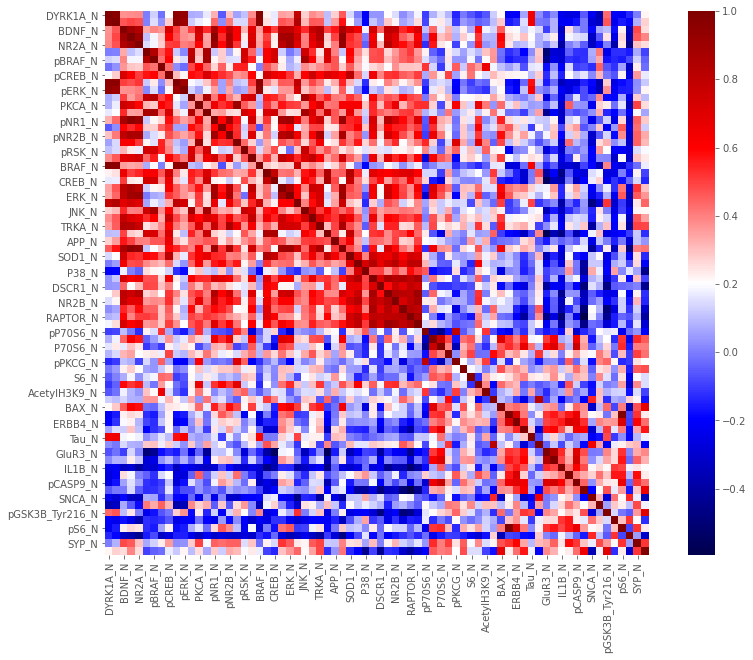

In [22]:
# correlation heatmap
plt.figure(figsize = (14, 10))
sns.heatmap(PCA_dataset.corr(), cmap = 'seismic', square = True)

In [23]:
# Separating out the features
x = PCA_dataset.loc[:, numerical].values

# Separating out the target
y = PCA_dataset.loc[:,['class']].values

# Standardizing the features
x = StandardScaler().fit_transform(x)

In [24]:
class_dataset = pd.DataFrame(data = y, columns = ['class'])

In [25]:
pca = PCA(n_components = 2)
principalComponents = pca.fit_transform(x)
principalDf = pd.DataFrame(data = principalComponents, 
                           columns = ['principal component 1', 'principal component 2'])

In [26]:
principalDf

,principal component 1,principal component 2
0,7.089490,-0.611511
1,8.868796,-1.052114
2,10.144306,-2.380156
3,5.559773,-1.925619
4,5.773950,-1.782481
...,...,...
265,1.666568,-2.309331
266,2.016233,-2.109346
267,1.614640,-4.009143
268,2.785608,-4.240107


In [27]:
finalDf = pd.concat([principalDf, class_dataset], axis = 1)

In [28]:
finalDf

,principal component 1,principal component 2,class
0,7.089490,-0.611511,c-CS-s
1,8.868796,-1.052114,c-CS-s
2,10.144306,-2.380156,c-CS-s
3,5.559773,-1.925619,c-CS-s
4,5.773950,-1.782481,c-CS-s
...,...,...,...
265,1.666568,-2.309331,t-CS-m
266,2.016233,-2.109346,t-CS-m
267,1.614640,-4.009143,t-CS-m
268,2.785608,-4.240107,t-CS-m


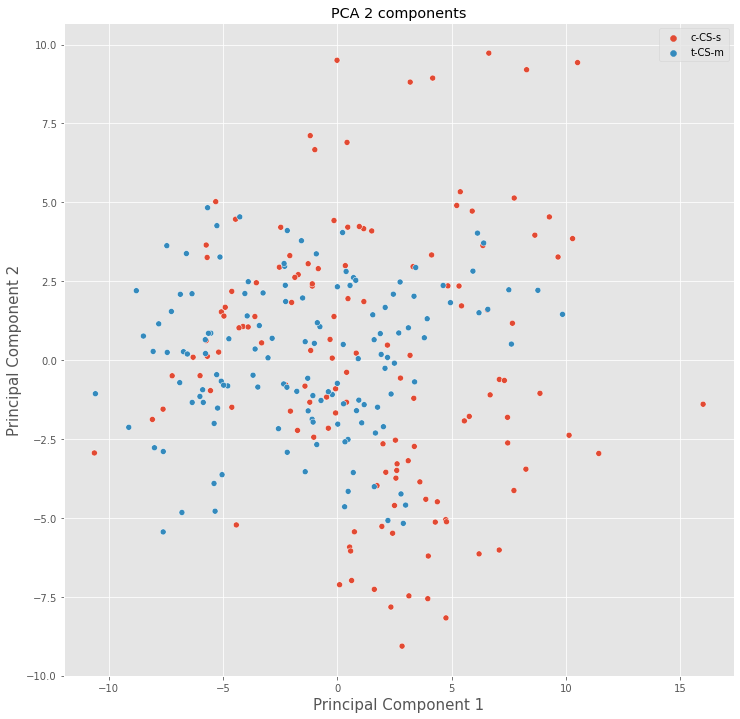

In [29]:
# 2d scatterplot
plt.figure(figsize = (12, 12));
plt.xlabel("Principal Component 1", fontsize = 15)
plt.ylabel("Principal Component 2", fontsize = 15)
sns.scatterplot(x = principalComponents[:,0], y = principalComponents[:,1], hue = PCA_dataset['class'])
plt.title('PCA 2 components')
plt.legend(loc = 'best')

In [30]:
# PCA1 has 30% significance
# PCA2 has 15% significance
pca.explained_variance_ratio_

array([0.30833348, 0.15688837])

In [31]:
pca.singular_values_

array([77.42094591, 55.22598928])

In [57]:
pca.explained_variance_

array([22.28253853, 11.33795499])

Text(0.5, 1.0, 'Cumulative Explained Variance')

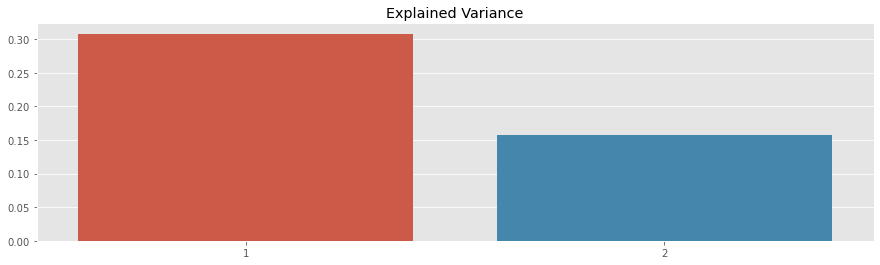

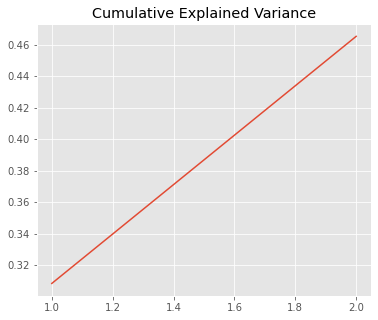

In [32]:
# explained variance
plt.figure(figsize = (15, 4));
sns.barplot(x = np.arange(pca.explained_variance_ratio_.shape[0])+1, 
            y = pca.explained_variance_ratio_)
plt.title('Explained Variance')

# cumulative explained variance
plt.figure(figsize = (6, 5))
sns.lineplot(x = np.arange(pca.explained_variance_ratio_.shape[0])+1, 
             y = pca.explained_variance_ratio_.cumsum())
plt.title('Cumulative Explained Variance')

# Find 3 most important Proteins

In [33]:
# identify most important features via Random Forest
ordinal = OrdinalEncoder()
labels = ordinal.fit_transform(PCA_dataset['class'].values[:, np.newaxis]).astype('int').squeeze()

forest = RandomForestClassifier(n_estimators = 1000, max_depth = 8, random_state = 42)
forest.fit(x, labels)

RandomForestClassifier(max_depth=8, n_estimators=1000, random_state=42)

Text(0.5, 1.0, 'Significance of Most Important Features')

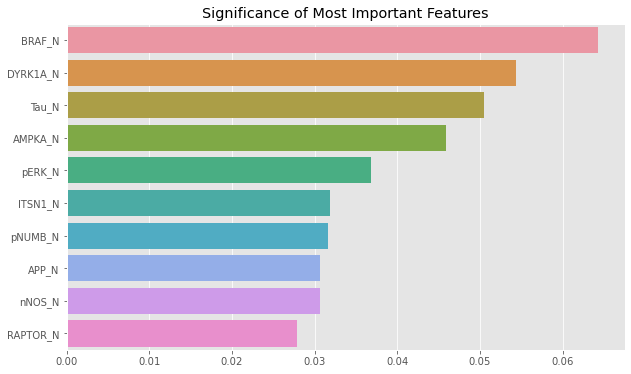

In [34]:
feats = np.argsort(forest.feature_importances_)[-10:]
plt.figure(figsize = (10, 6))
sns.barplot(y = PCA_dataset[numerical].columns[feats][::-1], 
            x = forest.feature_importances_[feats][::-1])
plt.title('Significance of Most Important Features')

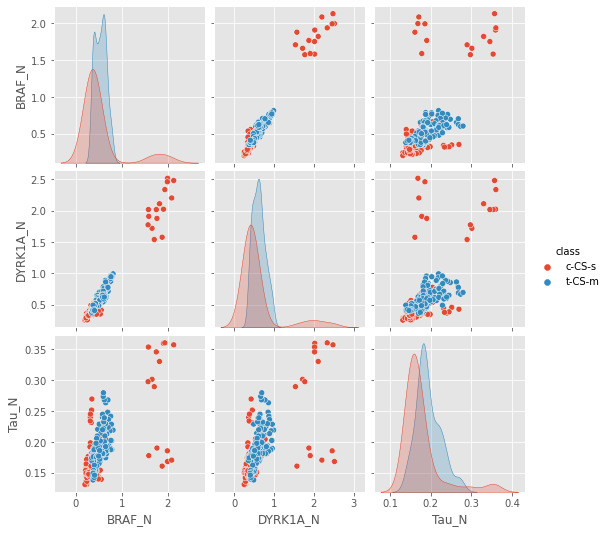

In [35]:
feats = ['BRAF_N', 'DYRK1A_N', 'Tau_N']

# pairplot
sns.pairplot(PCA_dataset, vars = feats, hue = 'class')

# SVC Evaluation

In [36]:
x = SVC_dataset.drop(['class'], axis = 1)
y = SVC_dataset['class']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 42)

In [38]:
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [39]:
classifier = SVC(gamma = 'scale')
classifier.fit(X_train, y_train)

SVC()

In [40]:
y_pred = classifier.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0,
       1, 1])

In [41]:
print('Accuracy of SVM classifier on test set: {:.2f}'.format(classifier.score(X_test, y_test)))

Accuracy of SVM classifier on test set: 1.00


In [42]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[35,  0],
       [ 0, 33]])

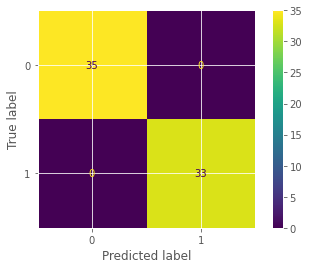

In [43]:
plot_confusion_matrix(classifier, X_test, y_test)  
plt.show()  

In [44]:
print(classifier.score(X_train, y_train))
print(classifier.score(X_test, y_test))

1.0
1.0
